In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

from specparam import SpectralGroupModel
from specparam.plts.spectra import plot_spectra


def specparam2pandas(fg):
    """
    Convert a SpectralGroupModel object into a long-format pandas DataFrame.
    One row per peak, with aperiodic parameters repeated per model.
    Spectra with no peaks are retained with NaN peak columns.
    """
    # rc6-style guard
    if not hasattr(fg, "results") or not getattr(fg.results, "has_model", False):
        raise ValueError("No model fit results available. Please fit the model first.")

    # Aperiodic params: one row per spectrum
    ap_params = fg.get_params("aperiodic")
    ap_labels = list(fg.modes.aperiodic.params.labels)

    specparam_aperiodic = pd.DataFrame(ap_params, columns=ap_labels)
    specparam_aperiodic["error_mae"] = fg.get_metrics("error", "mae")
    specparam_aperiodic["gof_rsquared"] = fg.get_metrics("gof", "rsquared")
    specparam_aperiodic = specparam_aperiodic.reset_index(names=["ID"])

    # Peak params
    peaks = fg.get_params("peak")

    if peaks.size > 0:
        peak_df = pd.DataFrame(peaks, columns=["CF", "PW", "BW", "ID"])
        peak_df["ID"] = peak_df["ID"].astype(int)
        result = specparam_aperiodic.merge(peak_df, on="ID", how="left")
    else:
        peak_df = pd.DataFrame(columns=["CF", "PW", "BW", "ID"])
        result = specparam_aperiodic.merge(peak_df, on="ID", how="left")

    return result


def examine_spectra_rc6(fg, spectra, subject):
    """Plot low / median / high exponent spectra and low / median / high R² spectra."""
    fit_df = specparam2pandas(fg)

    base = (
        fit_df[["ID", "exponent", "gof_rsquared"]]
        .drop_duplicates()
        .sort_values("ID")
        .reset_index(drop=True)
    )

    def argmedian_idx(values):
        order = np.argsort(values)
        return order[len(order) // 2]

    exp_vals = base["exponent"].to_numpy()
    r2_vals = base["gof_rsquared"].to_numpy()

    exp_ids = [
        int(base.iloc[np.argmin(exp_vals)]["ID"]),
        int(base.iloc[argmedian_idx(exp_vals)]["ID"]),
        int(base.iloc[np.argmax(exp_vals)]["ID"]),
    ]
    r2_ids = [
        int(base.iloc[np.argmin(r2_vals)]["ID"]),
        int(base.iloc[argmedian_idx(r2_vals)]["ID"]),
        int(base.iloc[np.argmax(r2_vals)]["ID"]),
    ]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    plot_spectra(
        fg.data.freqs,
        [spectra[i] for i in exp_ids],
        ax=ax[0],
        labels=[
            f"Low exponent {base.loc[base['ID'] == exp_ids[0], 'exponent'].iloc[0]:.2f}",
            f"Median exponent {base.loc[base['ID'] == exp_ids[1], 'exponent'].iloc[0]:.2f}",
            f"High exponent {base.loc[base['ID'] == exp_ids[2], 'exponent'].iloc[0]:.2f}",
        ],
    )
    ax[0].set_title("Spectra by exponent")

    plot_spectra(
        fg.data.freqs,
        [spectra[i] for i in r2_ids],
        ax=ax[1],
        labels=[
            f"Low R² {base.loc[base['ID'] == r2_ids[0], 'gof_rsquared'].iloc[0]:.2f}",
            f"Median R² {base.loc[base['ID'] == r2_ids[1], 'gof_rsquared'].iloc[0]:.2f}",
            f"High R² {base.loc[base['ID'] == r2_ids[2], 'gof_rsquared'].iloc[0]:.2f}",
        ],
    )
    ax[1].set_title("Spectra by R²")

    y0 = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
    y1 = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
    ax[0].set_ylim(y0, y1)
    ax[1].set_ylim(y0, y1)

    fig.suptitle(f"{subject} - rc6-safe spectrum inspection")
    plt.tight_layout()
    plt.show()


# cheap sanity check before the expensive fitting starts
assert callable(specparam2pandas)

Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 power spectra.
Fitting model across 80 p

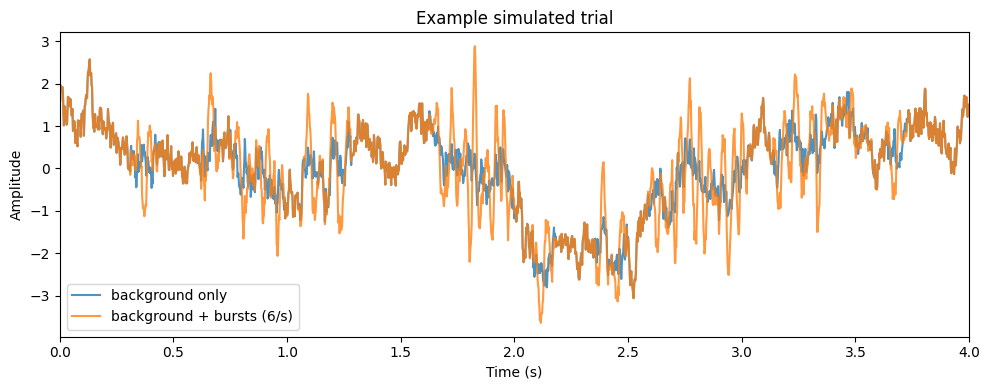

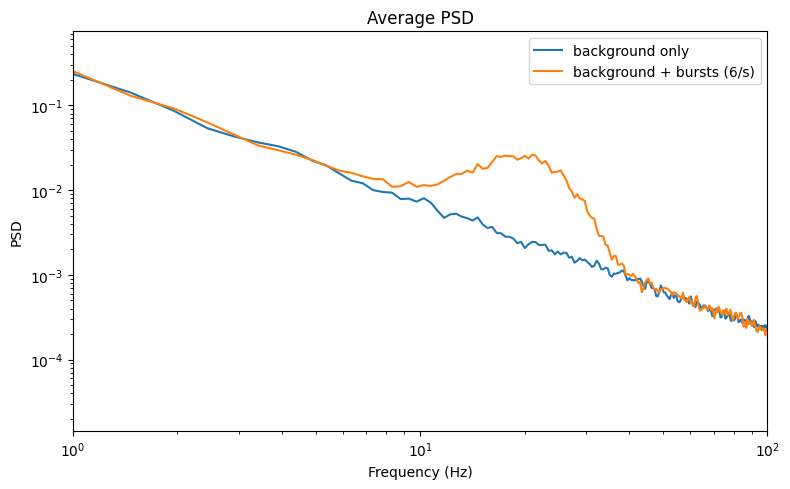

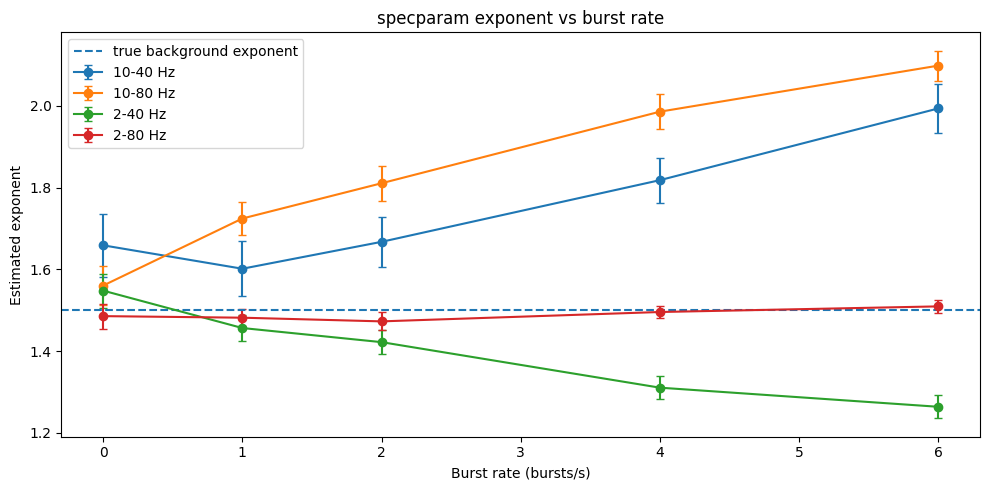

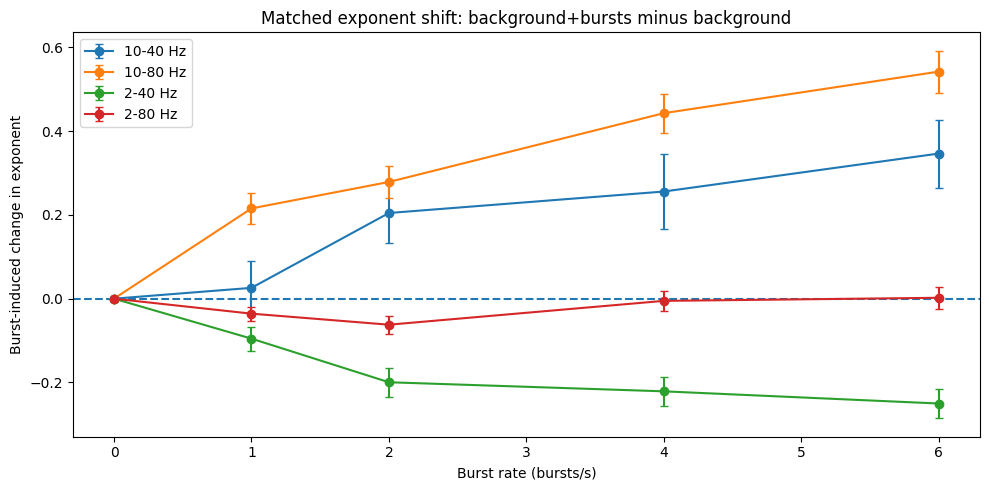

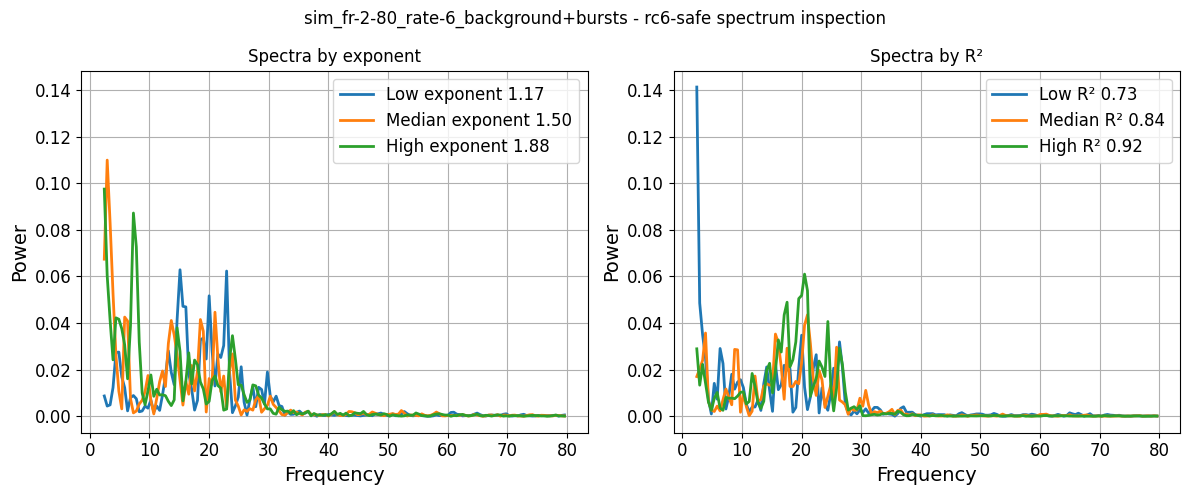

,fit_range,condition,burst_rate,exponent_mean,exponent_sd,offset_mean,error_mean,r2_mean,n,exponent_se
0,10-40,background,0,1.658945,0.683271,-0.806089,0.234117,0.492583,80,0.076392
1,10-40,background,1,1.575840,0.727554,-0.886136,0.238463,0.481717,80,0.081343
2,10-40,background,2,1.462978,0.736425,-1.042771,0.237463,0.466034,80,0.082335
3,10-40,background,4,1.562577,0.777863,-0.958317,0.232949,0.498635,80,0.086968
4,10-40,background,6,1.647390,0.718305,-0.785926,0.241603,0.482404,80,0.080309
5,10-40,background+bursts,0,1.658945,0.683271,-0.806089,0.234117,0.492583,80,0.076392
6,10-40,background+bursts,1,1.601670,0.601031,-0.690807,0.227008,0.590493,80,0.067197
7,10-40,background+bursts,2,1.667451,0.551712,-0.524309,0.221262,0.653767,80,0.061683
8,10-40,background+bursts,4,1.818308,0.494692,-0.201513,0.222366,0.717674,80,0.055308
9,10-40,background+bursts,6,1.993721,0.543974,0.168206,0.217193,0.759694,80,0.060818


,fit_range,burst_rate,delta_exponent_mean,delta_exponent_sd,delta_offset_mean,n,delta_exponent_se
0,10-40,0,0.000000,0.000000,0.000000,80,0.000000
1,10-40,1,0.025831,0.581463,0.195329,80,0.065010
2,10-40,2,0.204473,0.646001,0.518462,80,0.072225
3,10-40,4,0.255731,0.807720,0.756804,80,0.090306
4,10-40,6,0.346332,0.726723,0.954132,80,0.081250
5,10-80,0,0.000000,0.000000,0.000000,80,0.000000
6,10-80,1,0.215393,0.339623,0.408138,80,0.037971
7,10-80,2,0.278563,0.349626,0.564713,80,0.039089
8,10-80,4,0.442693,0.412969,0.863802,80,0.046171
9,10-80,6,0.541893,0.446118,1.072126,80,0.049878


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from specparam import SpectralGroupModel
from specparam.plts.spectra import plot_spectra


# ============================================================
# 1) Optional: rc6-safe replacement for your examine_spectra()
# ============================================================

def examine_spectra_rc6(fg, spectra, subject):
    """Plot low / median / high exponent spectra and low / median / high R^2 spectra."""
    fit_df = specparam2pandas(fg)

    base = (
        fit_df[["ID", "exponent", "gof_rsquared"]]
        .drop_duplicates()
        .sort_values("ID")
        .reset_index(drop=True)
    )

    def argmedian_idx(values):
        order = np.argsort(values)
        return order[len(order) // 2]

    exp_vals = base["exponent"].to_numpy()
    r2_vals = base["gof_rsquared"].to_numpy()

    exp_ids = [
        base.iloc[np.argmin(exp_vals)]["ID"],
        base.iloc[argmedian_idx(exp_vals)]["ID"],
        base.iloc[np.argmax(exp_vals)]["ID"],
    ]
    r2_ids = [
        base.iloc[np.argmin(r2_vals)]["ID"],
        base.iloc[argmedian_idx(r2_vals)]["ID"],
        base.iloc[np.argmax(r2_vals)]["ID"],
    ]

    exp_ids = [int(x) for x in exp_ids]
    r2_ids = [int(x) for x in r2_ids]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    plot_spectra(
        fg.data.freqs,
        [spectra[i] for i in exp_ids],
        ax=ax[0],
        labels=[
            f"Low exponent {base.loc[base['ID'] == exp_ids[0], 'exponent'].iloc[0]:.2f}",
            f"Median exponent {base.loc[base['ID'] == exp_ids[1], 'exponent'].iloc[0]:.2f}",
            f"High exponent {base.loc[base['ID'] == exp_ids[2], 'exponent'].iloc[0]:.2f}",
        ],
    )
    ax[0].set_title("Spectra by exponent")

    plot_spectra(
        fg.data.freqs,
        [spectra[i] for i in r2_ids],
        ax=ax[1],
        labels=[
            f"Low R² {base.loc[base['ID'] == r2_ids[0], 'gof_rsquared'].iloc[0]:.2f}",
            f"Median R² {base.loc[base['ID'] == r2_ids[1], 'gof_rsquared'].iloc[0]:.2f}",
            f"High R² {base.loc[base['ID'] == r2_ids[2], 'gof_rsquared'].iloc[0]:.2f}",
        ],
    )
    ax[1].set_title("Spectra by R²")

    y0 = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
    y1 = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
    ax[0].set_ylim(y0, y1)
    ax[1].set_ylim(y0, y1)

    fig.suptitle(f"{subject} - rc6-safe spectrum inspection")
    plt.tight_layout()
    plt.show()


# ============================================================
# 2) Simulation parameters
# ============================================================

fs = 500
duration = 4.0
n_samples = int(fs * duration)
n_trials = 80
nperseg = 1024
noverlap = nperseg // 2

true_exponent = 1.5
burst_rates = [0, 1, 2, 4, 6]      # bursts / second
fit_ranges = [(2, 40), (2, 80), (10, 40), (10, 80)]

burst_amp = 1.5
burst_f0 = 20.0
burst_f_jitter = 3.0
burst_dur_range = (0.08, 0.20)     # seconds
rng = np.random.default_rng(42)


# ============================================================
# 3) Signal simulation
# ============================================================

def powerlaw_noise(exponent, n_samples, fs, rng):
    """Approximate 1/f^exponent noise in the time domain."""
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)

    scale = np.zeros_like(freqs)
    scale[1:] = 1 / (freqs[1:] ** (exponent / 2))

    spectrum = (
        rng.normal(size=freqs.size) + 1j * rng.normal(size=freqs.size)
    ) * scale
    spectrum[0] = 0.0

    x = np.fft.irfft(spectrum, n=n_samples)
    x = (x - np.mean(x)) / np.std(x)
    return x


def add_beta_bursts(x, fs, rate_hz, amp, f0, f_jitter, dur_range, rng):
    """Add Gaussian-windowed beta bursts to a time series."""
    y = x.copy()
    t = np.arange(len(y)) / fs

    n_bursts = rng.poisson(rate_hz * duration)

    for _ in range(n_bursts):
        center = rng.uniform(0.3, duration - 0.3)
        dur = rng.uniform(*dur_range)
        freq = max(1.0, rng.normal(f0, f_jitter))
        phase = rng.uniform(0, 2 * np.pi)

        sigma = dur / 6.0
        envelope = np.exp(-0.5 * ((t - center) / sigma) ** 2)
        burst = amp * envelope * np.sin(2 * np.pi * freq * t + phase)

        y = y + burst

    return y


def compute_trial_psd(x, fs, nperseg, noverlap):
    freqs, psd = welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
    )
    return freqs, psd


def simulate_psd_matrices(rate_hz, n_trials, fs, n_samples, exponent, rng):
    """
    Simulate matched background-only and background+burst PSD matrices.
    Each burst trial is generated from the corresponding background trial.
    """
    bg_psds = []
    burst_psds = []
    example_bg = None
    example_burst = None

    for i in range(n_trials):
        bg = powerlaw_noise(exponent, n_samples, fs, rng)
        burst = add_beta_bursts(
            bg,
            fs=fs,
            rate_hz=rate_hz,
            amp=burst_amp,
            f0=burst_f0,
            f_jitter=burst_f_jitter,
            dur_range=burst_dur_range,
            rng=rng,
        )

        freqs, bg_psd = compute_trial_psd(bg, fs, nperseg, noverlap)
        _, burst_psd = compute_trial_psd(burst, fs, nperseg, noverlap)

        bg_psds.append(bg_psd)
        burst_psds.append(burst_psd)

        if i == 0:
            example_bg = bg
            example_burst = burst

    return (
        freqs,
        np.vstack(bg_psds),
        np.vstack(burst_psds),
        example_bg,
        example_burst,
    )


# ============================================================
# 4) specparam fitting
# ============================================================

def crop_spectra(freqs, spectra, fit_range):
    mask = (freqs >= fit_range[0]) & (freqs <= fit_range[1])
    return freqs[mask], spectra[:, mask]


def fit_group_specparam(freqs, spectra, fit_range):
    """
    Fit a SpectralGroupModel on cropped spectra.
    """
    f_fit, s_fit = crop_spectra(freqs, spectra, fit_range)

    fg = SpectralGroupModel(
        peak_width_limits=[2.0, 14.0],
        max_n_peaks=4,
        min_peak_height=0.05,
        peak_threshold=2.0,
        aperiodic_mode="fixed",
    )
    fg.fit(f_fit, s_fit)
    return fg, f_fit, s_fit


def extract_aperiodic_only(df):
    cols = [c for c in ["ID", "offset", "exponent", "knee", "error_mae", "gof_rsquared"] if c in df.columns]
    return df[cols].drop_duplicates().copy()


# ============================================================
# 5) Run simulation + model fitting
# ============================================================

all_rows = []
paired_rows = []
stored_groups = {}
stored_spectra = {}
stored_examples = {}

for fit_range in fit_ranges:
    for rate in burst_rates:
        freqs, bg_spectra, burst_spectra, example_bg, example_burst = simulate_psd_matrices(
            rate_hz=rate,
            n_trials=n_trials,
            fs=fs,
            n_samples=n_samples,
            exponent=true_exponent,
            rng=rng,
        )

        fg_bg, f_bg_fit, s_bg_fit = fit_group_specparam(freqs, bg_spectra, fit_range)
        fg_burst, f_burst_fit, s_burst_fit = fit_group_specparam(freqs, burst_spectra, fit_range)

        df_bg = specparam2pandas(fg_bg)
        df_bg["condition"] = "background"
        df_bg["burst_rate"] = rate
        df_bg["fit_range"] = f"{fit_range[0]}-{fit_range[1]}"

        df_burst = specparam2pandas(fg_burst)
        df_burst["condition"] = "background+bursts"
        df_burst["burst_rate"] = rate
        df_burst["fit_range"] = f"{fit_range[0]}-{fit_range[1]}"

        all_rows.append(df_bg)
        all_rows.append(df_burst)

        ap_bg = extract_aperiodic_only(df_bg).rename(
            columns={
                "offset": "offset_bg",
                "exponent": "exponent_bg",
                "error_mae": "error_bg",
                "gof_rsquared": "r2_bg",
            }
        )
        ap_burst = extract_aperiodic_only(df_burst).rename(
            columns={
                "offset": "offset_burst",
                "exponent": "exponent_burst",
                "error_mae": "error_burst",
                "gof_rsquared": "r2_burst",
            }
        )

        paired = ap_bg.merge(ap_burst, on="ID", how="inner")
        paired["burst_rate"] = rate
        paired["fit_range"] = f"{fit_range[0]}-{fit_range[1]}"
        paired["delta_exponent"] = paired["exponent_burst"] - paired["exponent_bg"]
        paired["delta_offset"] = paired["offset_burst"] - paired["offset_bg"]
        paired_rows.append(paired)

        stored_groups[(fit_range, rate, "background")] = fg_bg
        stored_groups[(fit_range, rate, "background+bursts")] = fg_burst
        stored_spectra[(fit_range, rate, "background")] = s_bg_fit
        stored_spectra[(fit_range, rate, "background+bursts")] = s_burst_fit
        stored_examples[(fit_range, rate)] = {
            "example_bg": example_bg,
            "example_burst": example_burst,
            "freqs": freqs,
            "bg_mean_psd": bg_spectra.mean(axis=0),
            "burst_mean_psd": burst_spectra.mean(axis=0),
        }

results_long = pd.concat(all_rows, ignore_index=True)
paired_results = pd.concat(paired_rows, ignore_index=True)

aperiodic_results = (
    results_long[[c for c in ["ID", "condition", "burst_rate", "fit_range", "offset", "exponent", "knee", "error_mae", "gof_rsquared"] if c in results_long.columns]]
    .drop_duplicates()
    .reset_index(drop=True)
)


# ============================================================
# 6) Summaries
# ============================================================

summary = (
    aperiodic_results
    .groupby(["fit_range", "condition", "burst_rate"], as_index=False)
    .agg(
        exponent_mean=("exponent", "mean"),
        exponent_sd=("exponent", "std"),
        offset_mean=("offset", "mean"),
        error_mean=("error_mae", "mean"),
        r2_mean=("gof_rsquared", "mean"),
        n=("ID", "count"),
    )
)
summary["exponent_se"] = summary["exponent_sd"] / np.sqrt(summary["n"])

paired_summary = (
    paired_results
    .groupby(["fit_range", "burst_rate"], as_index=False)
    .agg(
        delta_exponent_mean=("delta_exponent", "mean"),
        delta_exponent_sd=("delta_exponent", "std"),
        delta_offset_mean=("delta_offset", "mean"),
        n=("ID", "count"),
    )
)
paired_summary["delta_exponent_se"] = paired_summary["delta_exponent_sd"] / np.sqrt(paired_summary["n"])


# ============================================================
# 7) Plot example time series
# ============================================================

chosen_rate = burst_rates[-1]
example = stored_examples[((2, 80), chosen_rate)]
t = np.arange(n_samples) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, example["example_bg"], label="background only", alpha=0.8)
plt.plot(t, example["example_burst"], label=f"background + bursts ({chosen_rate}/s)", alpha=0.8)
plt.xlim(0, duration)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Example simulated trial")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8) Plot average PSD
# ============================================================

plt.figure(figsize=(8, 5))
plt.loglog(example["freqs"], stored_examples[((2, 80), 0)]["bg_mean_psd"], label="background only")
plt.loglog(example["freqs"], example["burst_mean_psd"], label=f"background + bursts ({chosen_rate}/s)")
plt.xlim(1, 100)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Average PSD")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9) Plot specparam exponent vs burst rate
# ============================================================

plt.figure(figsize=(10, 5))

for fit_range_label, subdf in summary[summary["condition"] == "background+bursts"].groupby("fit_range"):
    plt.errorbar(
        subdf["burst_rate"],
        subdf["exponent_mean"],
        yerr=subdf["exponent_se"],
        marker="o",
        capsize=3,
        label=f"{fit_range_label} Hz",
    )

plt.axhline(true_exponent, linestyle="--", label="true background exponent")
plt.xlabel("Burst rate (bursts/s)")
plt.ylabel("Estimated exponent")
plt.title("specparam exponent vs burst rate")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 10) Plot matched burst-induced exponent shift
# ============================================================

plt.figure(figsize=(10, 5))

for fit_range_label, subdf in paired_summary.groupby("fit_range"):
    plt.errorbar(
        subdf["burst_rate"],
        subdf["delta_exponent_mean"],
        yerr=subdf["delta_exponent_se"],
        marker="o",
        capsize=3,
        label=f"{fit_range_label} Hz",
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Burst rate (bursts/s)")
plt.ylabel("Burst-induced change in exponent")
plt.title("Matched exponent shift: background+bursts minus background")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11) Inspect one fitted group
# ============================================================

fit_range_to_inspect = (2, 80)
rate_to_inspect = 6
condition_to_inspect = "background+bursts"

fg_inspect = stored_groups[(fit_range_to_inspect, rate_to_inspect, condition_to_inspect)]
spectra_inspect = stored_spectra[(fit_range_to_inspect, rate_to_inspect, condition_to_inspect)]

examine_spectra_rc6(
    fg_inspect,
    spectra_inspect,
    subject=f"sim_fr-{fit_range_to_inspect[0]}-{fit_range_to_inspect[1]}_rate-{rate_to_inspect}_{condition_to_inspect}",
)


# ============================================================
# 12) Show tables
# ============================================================

display(summary.sort_values(["fit_range", "condition", "burst_rate"]))
display(paired_summary.sort_values(["fit_range", "burst_rate"]))

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from specparam.plts.spectra import plot_spectra


def _aperiodic_curve(freqs, offset, exponent, knee=None):
    """
    Reconstruct the aperiodic fit in linear power units.

    fixed mode:
        P(f) = 10**offset / f**exponent

    knee mode:
        P(f) = 10**offset / (knee + f**exponent)
    """
    freqs = np.asarray(freqs)

    if knee is None or np.isnan(knee):
        return 10 ** offset / (freqs ** exponent)
    else:
        return 10 ** offset / (knee + freqs ** exponent)


def examine_spectra_with_aperiodic_overlay(fg, spectra, subject):
    """
    Plot example spectra selected by low / median / high exponent and R²,
    with the fitted aperiodic (1/f) curve overlaid as dashed lines.

    Parameters
    ----------
    fg : SpectralGroupModel
        Fitted specparam group model.
    spectra : 2D array, shape (n_spectra, n_freqs)
        The exact spectra matrix that was passed to fg.fit(...), cropped to fg.data.freqs.
    subject : str
        Label for the figure title.
    """
    fit_df = specparam2pandas(fg)

    cols = ["ID", "offset", "exponent", "gof_rsquared"]
    if "knee" in fit_df.columns:
        cols.append("knee")

    base = (
        fit_df[cols]
        .drop_duplicates()
        .sort_values("ID")
        .reset_index(drop=True)
    )

    def argmedian(arr):
        return np.argsort(arr)[len(arr) // 2]

    exps = base["exponent"].to_numpy()
    r2s = base["gof_rsquared"].to_numpy()

    exp_ids = [
        int(base.iloc[np.argmin(exps)]["ID"]),
        int(base.iloc[argmedian(exps)]["ID"]),
        int(base.iloc[np.argmax(exps)]["ID"]),
    ]

    r2_ids = [
        int(base.iloc[np.argmin(r2s)]["ID"]),
        int(base.iloc[argmedian(r2s)]["ID"]),
        int(base.iloc[np.argmax(r2s)]["ID"]),
    ]

    fig, ax = plt.subplots(1, 2, figsize=(13, 6))
    colors = ["C0", "C1", "C2"]

    # ----- left panel: low / median / high exponent -----
    exp_spectra = [spectra[i] for i in exp_ids]
    exp_labels = [
        f"Low exponent {base.loc[base['ID'] == exp_ids[0], 'exponent'].iloc[0]:.2f}",
        f"Median exponent {base.loc[base['ID'] == exp_ids[1], 'exponent'].iloc[0]:.2f}",
        f"High exponent {base.loc[base['ID'] == exp_ids[2], 'exponent'].iloc[0]:.2f}",
    ]

    plot_spectra(
        fg.data.freqs,
        exp_spectra,
        ax=ax[0],
        labels=exp_labels,
        colors=colors,
    )

    for idx, color in zip(exp_ids, colors):
        row = base.loc[base["ID"] == idx].iloc[0]
        knee = row["knee"] if "knee" in base.columns else None
        ap_fit = _aperiodic_curve(
            fg.data.freqs,
            offset=row["offset"],
            exponent=row["exponent"],
            knee=knee,
        )
        ax[0].plot(
            fg.data.freqs,
            ap_fit,
            linestyle="--",
            linewidth=2,
            color=color,
            alpha=0.9,
        )

    ax[0].set_title("Spectra by exponent\n(dashed = fitted aperiodic)")

    # ----- right panel: low / median / high R² -----
    r2_spectra = [spectra[i] for i in r2_ids]
    r2_labels = [
        f"Low R² {base.loc[base['ID'] == r2_ids[0], 'gof_rsquared'].iloc[0]:.2f}",
        f"Median R² {base.loc[base['ID'] == r2_ids[1], 'gof_rsquared'].iloc[0]:.2f}",
        f"High R² {base.loc[base['ID'] == r2_ids[2], 'gof_rsquared'].iloc[0]:.2f}",
    ]

    plot_spectra(
        fg.data.freqs,
        r2_spectra,
        ax=ax[1],
        labels=r2_labels,
        colors=colors,
    )

    for idx, color in zip(r2_ids, colors):
        row = base.loc[base["ID"] == idx].iloc[0]
        knee = row["knee"] if "knee" in base.columns else None
        ap_fit = _aperiodic_curve(
            fg.data.freqs,
            offset=row["offset"],
            exponent=row["exponent"],
            knee=knee,
        )
        ax[1].plot(
            fg.data.freqs,
            ap_fit,
            linestyle="--",
            linewidth=2,
            color=color,
            alpha=0.9,
        )

    ax[1].set_title("Spectra by R²\n(dashed = fitted aperiodic)")

    # Match y-limits across panels
    ylim1 = ax[0].get_ylim()
    ylim2 = ax[1].get_ylim()
    y0 = min(ylim1[0], ylim2[0])
    y1 = max(ylim1[1], ylim2[1])
    ax[0].set_ylim(y0, y1)
    ax[1].set_ylim(y0, y1)

    fig.suptitle(
        f"sub-{subject} - spectra with fitted aperiodic overlays",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

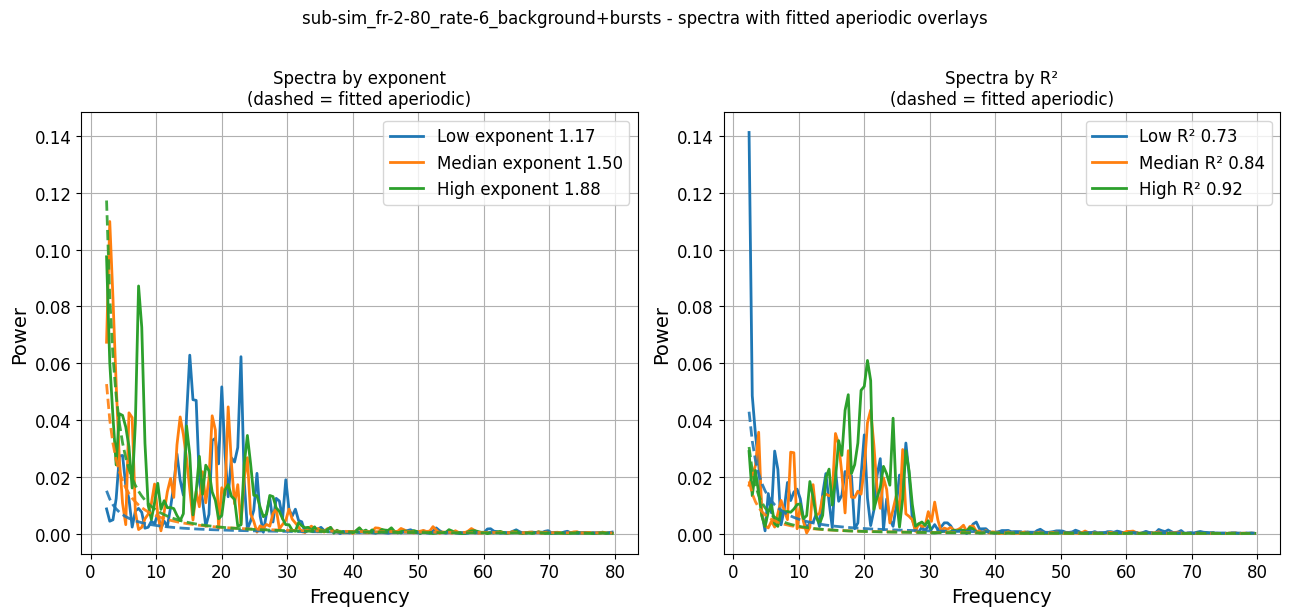

In [6]:
fit_range_to_inspect = (2, 80)
rate_to_inspect = 6
condition_to_inspect = "background+bursts"

fg_inspect = stored_groups[(fit_range_to_inspect, rate_to_inspect, condition_to_inspect)]
spectra_inspect = stored_spectra[(fit_range_to_inspect, rate_to_inspect, condition_to_inspect)]

examine_spectra_with_aperiodic_overlay(
    fg_inspect,
    spectra_inspect,
    subject=f"sim_fr-{fit_range_to_inspect[0]}-{fit_range_to_inspect[1]}_rate-{rate_to_inspect}_{condition_to_inspect}",
)